In [46]:
import sys
import time
import torch
import numpy as np
import torch.nn as nn
from tqdm import trange
from pathlib import Path
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset
# # import  settings

sys.path.append('..')
import plot_settings
plot_settings.apply()


import importlib
import sim_PyBaMM
importlib.reload(sim_PyBaMM)

import exp_pybamm
importlib.reload(exp_pybamm)

<module 'exp_pybamm' from '/Users/noord/Library/CloudStorage/OneDrive-Chalmers/Master2/MSc_thesis/program/PINN/../exp_pybamm.py'>

In [47]:
# Directory of THIS script
BASE_DIR = Path.cwd()
I = np.load(BASE_DIR.parent / 'NO/data_NO/I.npz')['arr_0']   # [N,1,1000]
V = np.load(BASE_DIR.parent / 'NO/data_NO/V.npz')['arr_0']   # [N,1,1000]

test_size = 0.1
split = int(test_size * len(I))

I_test = I[:split]
V_test = V[:split]
I_train = I[split:]
V_train = V[split:]

# reshape to (samples, 1000)
I_train = I_train.reshape(I_train.shape[0], -1)
V_train = V_train.reshape(V_train.shape[0], -1)
I_test  = I_test.reshape(I_test.shape[0], -1)
V_test  = V_test.reshape(V_test.shape[0], -1)

# Normalize (from train set only)
scaler_I = StandardScaler()
scaler_V = StandardScaler()
I_train = scaler_I.fit_transform(I_train)
V_train = scaler_V.fit_transform(V_train)
I_test = scaler_I.transform(I_test)
V_test = scaler_V.transform(V_test)

# Convert to PyTorch tensors
train_dataset = TensorDataset(
    torch.tensor(I_train, dtype=torch.float32),
    torch.tensor(V_train, dtype=torch.float32)
)

loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

In [48]:
model = nn.Sequential(
    nn.Linear(1000, 512),
    nn.ReLU(),
    nn.Linear(512, 512),
    nn.ReLU(),
    nn.Linear(512, 1000)
)

optimizer = optim.Adam(model.parameters(), lr=1e-3)

# loss functions
def data_loss(u_pred, u_true):
    loss_fn = nn.MSELoss()
    return loss_fn(u_pred, u_true)


# time points (collocation)
t = torch.linspace(0, 1, 100).view(-1,1)
t.requires_grad = True

def physics_loss(u, t):
    # compute du/dt
    du_dt = torch.autograd.grad(outputs=u, inputs=t,
                                grad_outputs=torch.ones_like(u), create_graph=True)[0]
    # PDE residual for du/dt + u = 0
    return torch.mean((du_dt + u)**2)

In [49]:
def training(epochs=50, tol=2.5e-4, loader=loader, model=model, optimizer=optimizer):
    history = {'loss': []}
    
    for epoch in range(epochs):
        loss_sum = 0
        nb = 0
        start_b = time.perf_counter()

        for u_batch, y_batch in loader:
            # reshape: [B,1,1000] → [B,1000]
            u_batch = u_batch.squeeze(1)
            y_batch = y_batch.squeeze(1)

            y_pred = model(u_batch)

            d_loss = data_loss(y_pred, y_batch)
            loss = d_loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        #     loss_sum += loss.item()
        #     nb += 1

        # end_b = time.perf_counter()
        # avg_loss = loss_sum / nb
        # ETA = (end_b-start_b)*(epochs-epoch-1)

        history['loss'].append(loss.item())

        if loss < tol:
            print(f'Epoch {epoch+1} loss: {loss:.5f} - Early stopping')
            break

        print(f'Epoch {epoch+1} loss: {loss:.5f}')

    return model, history

In [50]:
model, history = training(epochs=500, model=model, optimizer=optimizer)

Epoch 1 loss: 0.92620
Epoch 2 loss: 0.69510
Epoch 3 loss: 0.57462
Epoch 4 loss: 0.44792
Epoch 5 loss: 0.35406
Epoch 6 loss: 0.31247
Epoch 7 loss: 0.25960
Epoch 8 loss: 0.21867
Epoch 9 loss: 0.18826
Epoch 10 loss: 0.15912
Epoch 11 loss: 0.14262
Epoch 12 loss: 0.12636
Epoch 13 loss: 0.11786
Epoch 14 loss: 0.09995
Epoch 15 loss: 0.09128
Epoch 16 loss: 0.08516
Epoch 17 loss: 0.07319
Epoch 18 loss: 0.06787
Epoch 19 loss: 0.06160
Epoch 20 loss: 0.05621
Epoch 21 loss: 0.05225
Epoch 22 loss: 0.04856
Epoch 23 loss: 0.04405
Epoch 24 loss: 0.04248
Epoch 25 loss: 0.03946
Epoch 26 loss: 0.03697
Epoch 27 loss: 0.03568
Epoch 28 loss: 0.03032
Epoch 29 loss: 0.03009
Epoch 30 loss: 0.02861
Epoch 31 loss: 0.02648
Epoch 32 loss: 0.02616
Epoch 33 loss: 0.02146
Epoch 34 loss: 0.02242
Epoch 35 loss: 0.02403
Epoch 36 loss: 0.02148
Epoch 37 loss: 0.02182
Epoch 38 loss: 0.01852
Epoch 39 loss: 0.02008
Epoch 40 loss: 0.01843
Epoch 41 loss: 0.01728
Epoch 42 loss: 0.01767
Epoch 43 loss: 0.01569
Epoch 44 loss: 0.016

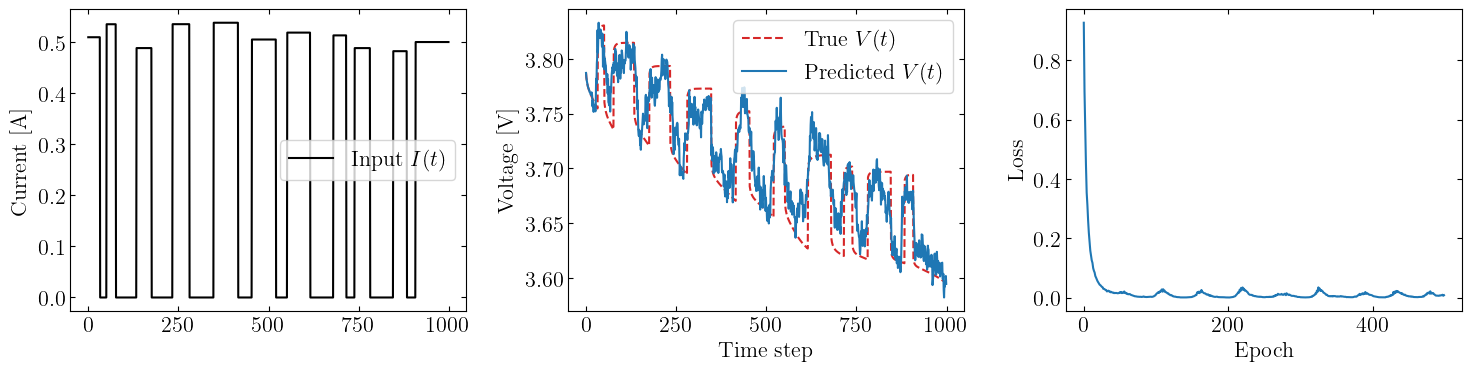

In [51]:
test = 1
i = I_test[test].reshape(1, -1)  # [1,1000]
v = V_test[test].reshape(1, -1)  # [1,1000]

i_tensor = torch.tensor(i, dtype=torch.float32)

with torch.no_grad():
    y_pred = model(i_tensor)

# Inverse transform to original scale
i = scaler_I.inverse_transform(i)
v = scaler_V.inverse_transform(v)
y_pred = scaler_V.inverse_transform(y_pred.numpy())

# Plot
f, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15,4))

ax1.plot(i.ravel(), label='Input $I(t)$', color='black')
ax2.plot(v.ravel(), label='True $V(t)$', color='tab:red', linestyle='dashed')
ax2.plot(y_pred.ravel(), label='Predicted $V(t)$', color='tab:blue')

ax2.legend()
ax1.legend()
ax2.set_xlabel('Time step')
ax1.set_ylabel('Current [A]')
ax2.set_ylabel('Voltage [V]')

ax3.plot(history['loss'])
ax3.set_xlabel('Epoch')
ax3.set_ylabel('Loss')  
plt.tight_layout()